## Data Sourcing

**Concept:** Fetching and Saving the California Housing Dataset

In [ ]:
import os
import certifi
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Use the certifi certificate bundle for HTTPS connections
os.environ["SSL_CERT_FILE"] = certifi.where()

# 1. Fetch the dataset with dataframe format enabled from scikit-learn
california = fetch_california_housing(as_frame=True)
df_california = california.frame

# 2. Ensure the raw data directory exists
os.makedirs('../data/raw', exist_ok=True)

# 3. Save the dataframe to a CSV file
df_california.to_csv('../data/raw/california_housing.csv', index=False)

print("Dataset successfully saved to data/raw/california_housing.csv!")
print("First few rows of the dataset:")
print(df_california.head())
print("Shape of dataset:", df_california.shape)
print("Column names:")
print(df_california.columns.tolist())
print("Dataset Information:")
df_california.info()
print("Dataset Description:")
df_california.describe()
print("Missing Values:")
print(df_california.isnull().sum())

Dataset successfully saved to data/raw/california_housing.csv!
Shape of dataset: (20640, 9)
First few rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Shape of dataset: (20640, 9)
Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data colu

## Relationship Between Median Income and Median House Value

We examine whether median income has a relationship with median house value.
Median income will be used as the predictor (X), while median house value
will be used as the target (y).

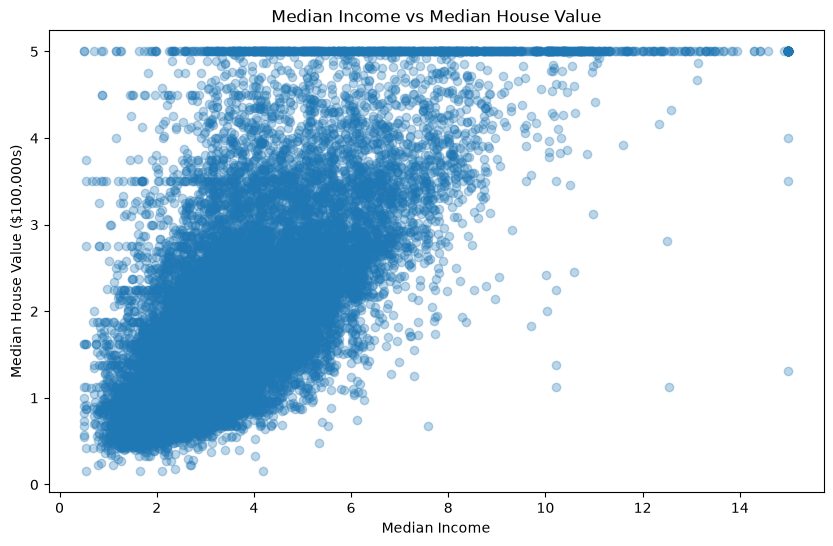

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_california["MedInc"],
    df_california["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Median Income vs Median House Value")

plt.show()

## Measure the relationship numerically

In [10]:
correlation = df_california["MedInc"].corr(
    df_california["MedHouseVal"]
)

print("Correlation:", correlation)

Correlation: 0.6880752079585479


## X And Y
Now we will create X and Y variables which we will eventually give to our model to train it

In [12]:
X = df_california[["MedInc"]]
y = df_california["MedHouseVal"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 1)
y shape: (20640,)


## Ontario Housing Data Analysis

#### Load the data

In [2]:
import pandas as pd

df_ontario = pd.read_csv("../data/raw/ontario_housing.csv")

print("Dataset loaded successfully!")
print("Shape:", df_ontario.shape)
df_ontario.head()

Dataset loaded successfully!
Shape: (65760, 15)


,REF_DATE,GEO,DGUID,New housing price indexes,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2016A000011124,Total (house and land),"Index, 201612=100",347,units,0,v111955442,1.1,38.2,NaN,NaN,NaN,1
1,1981-01,Canada,2016A000011124,House only,"Index, 201612=100",347,units,0,v111955443,1.2,36.1,NaN,NaN,NaN,1
2,1981-01,Canada,2016A000011124,Land only,"Index, 201612=100",347,units,0,v111955444,1.3,40.6,E,NaN,NaN,1
3,1981-01,Atlantic Region,2016A00011,Total (house and land),"Index, 201612=100",347,units,0,v111955445,2.1,NaN,..,NaN,NaN,1
4,1981-01,Atlantic Region,2016A00011,House only,"Index, 201612=100",347,units,0,v111955446,2.2,NaN,..,NaN,NaN,1


#### Look at all column names and look for basic structure

In [4]:
print(df_ontario.columns.tolist())
df_ontario.info()

['REF_DATE', 'GEO', 'DGUID', 'New housing price indexes', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']
<class 'pandas.DataFrame'>
RangeIndex: 65760 entries, 0 to 65759
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   REF_DATE                   65760 non-null  str    
 1   GEO                        65760 non-null  str    
 2   DGUID                      64116 non-null  str    
 3   New housing price indexes  65760 non-null  str    
 4   UOM                        65760 non-null  str    
 5   UOM_ID                     65760 non-null  int64  
 6   SCALAR_FACTOR              65760 non-null  str    
 7   SCALAR_ID                  65760 non-null  int64  
 8   VECTOR                     65760 non-null  str    
 9   COORDINATE                 65760 non-null  float64
 10  VALUE                      54934 non-null

In [5]:
print("GEO" in df_ontario.columns)

True


#### To check all the locations in data for filtering

In [6]:
print(df_ontario["GEO"].unique())

<StringArray>
[                                             'Canada',
                                     'Atlantic Region',
                           'Newfoundland and Labrador',
               'St. John's, Newfoundland and Labrador',
                                'Prince Edward Island',
                 'Charlottetown, Prince Edward Island',
                                         'Nova Scotia',
                                'Halifax, Nova Scotia',
                                       'New Brunswick',
 'Saint John, Fredericton, and Moncton, New Brunswick',
                                              'Quebec',
                                      'Québec, Quebec',
                                  'Sherbrooke, Quebec',
                              'Trois-Rivières, Quebec',
                                    'Montréal, Quebec',
        'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
                                             'Ontario',
       'Ottawa-Gatineau, Ontario p

#### Now, we will filter the dataset to only include rows where the "GEO" column is equal to "Ontario".

In [12]:
df_ontario_filtered = df_ontario[
    df_ontario["GEO"] == "Ontario"
].copy()

print("Original shape:", df_ontario.shape)
print("Ontario shape:", df_ontario_filtered.shape)


Original shape: (65760, 15)
Ontario shape: (1644, 15)


In [14]:
print(df_ontario_filtered["GEO"].unique())
df_ontario_filtered.head()

<StringArray>
['Ontario']
Length: 1, dtype: str


,REF_DATE,GEO,DGUID,New housing price indexes,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
48,1981-01,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
49,1981-01,Ontario,2016A000235,House only,"Index, 201612=100",347,units,0,v111955491,17.2,NaN,..,NaN,NaN,1
50,1981-01,Ontario,2016A000235,Land only,"Index, 201612=100",347,units,0,v111955492,17.3,NaN,..,NaN,NaN,1
168,1981-02,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
169,1981-02,Ontario,2016A000235,House only,"Index, 201612=100",347,units,0,v111955491,17.2,NaN,..,NaN,NaN,1


#### Now housing measurements we have

In [15]:
print(df_ontario_filtered.columns.tolist())

['REF_DATE', 'GEO', 'DGUID', 'New housing price indexes', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


In [17]:
for column in df_ontario_filtered.columns:
    if df_ontario_filtered[column].dtype == "object":
        print("\nCOLUMN:", column)
        print(df_ontario_filtered[column].unique()[:20])

In [18]:
print(
    df_ontario_filtered["New housing price indexes"].unique()
)

<StringArray>
['Total (house and land)', 'House only', 'Land only']
Length: 3, dtype: str


#### Filter to total (House and Land)

In [19]:
df_ontario_clean = df_ontario_filtered[
    df_ontario_filtered["New housing price indexes"] == "Total (house and land)"
].copy()

print("Rows before:", df_ontario_filtered.shape)
print("Rows after:", df_ontario_clean.shape)

df_ontario_clean.head()

Rows before: (1644, 15)
Rows after: (548, 15)


,REF_DATE,GEO,DGUID,New housing price indexes,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
48,1981-01,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
168,1981-02,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
288,1981-03,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
408,1981-04,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1
528,1981-05,Ontario,2016A000235,Total (house and land),"Index, 201612=100",347,units,0,v111955490,17.1,NaN,..,NaN,NaN,1


## Keep only useful columns
We are not using all the column, we are onnly using the required one's

In [20]:
df_ontario_clean = df_ontario_clean[
    [
        "REF_DATE",
        "GEO",
        "New housing price indexes",
        "VALUE"
    ]
].copy()

df_ontario_clean.head()

,REF_DATE,GEO,New housing price indexes,VALUE
48,1981-01,Ontario,Total (house and land),NaN
168,1981-02,Ontario,Total (house and land),NaN
288,1981-03,Ontario,Total (house and land),NaN
408,1981-04,Ontario,Total (house and land),NaN
528,1981-05,Ontario,Total (house and land),NaN


## Give the columns simpler names
To understand the dataset better, we can rename the columns to simpler names. This will make it easier to work with the data in subsequent analysis and modeling steps.

In [21]:
df_ontario_clean = df_ontario_clean.rename(
    columns={
        "REF_DATE": "date",
        "GEO": "province",
        "New housing price indexes": "index_type",
        "VALUE": "price_index"
    }
)

df_ontario_clean.head()

,date,province,index_type,price_index
48,1981-01,Ontario,Total (house and land),NaN
168,1981-02,Ontario,Total (house and land),NaN
288,1981-03,Ontario,Total (house and land),NaN
408,1981-04,Ontario,Total (house and land),NaN
528,1981-05,Ontario,Total (house and land),NaN


### Check Missing Values and datatypes

In [23]:
print(df_ontario_clean.isnull().sum())
print(df_ontario_clean.dtypes)

date            0
province        0
index_type      0
price_index    60
dtype: int64
date               str
province           str
index_type         str
price_index    float64
dtype: object


### Remove rows with missing price_index

In [24]:
df_ontario_clean = df_ontario_clean.dropna(
    subset=["price_index"]
)

print(df_ontario_clean.isnull().sum())

date           0
province       0
index_type     0
price_index    0
dtype: int64


### Convert date into an actual date and sort by date

In [27]:
df_ontario_clean["date"] = pd.to_datetime(
    df_ontario_clean["date"]
)
print(df_ontario_clean.dtypes)

df_ontario_clean = df_ontario_clean.sort_values(
    by="date"
)

df_ontario_clean.head()

date           datetime64[us]
province                  str
index_type                str
price_index           float64
dtype: object


,date,province,index_type,price_index
7248,1986-01-01,Ontario,Total (house and land),36.7
7368,1986-02-01,Ontario,Total (house and land),37.3
7488,1986-03-01,Ontario,Total (house and land),37.7
7608,1986-04-01,Ontario,Total (house and land),38.0
7728,1986-05-01,Ontario,Total (house and land),38.4


## Save and print the processed dataset 🎉

In [28]:
df_ontario_clean.to_csv(
    "../data/processed/ontario_housing_clean.csv",
    index=False
)

print("Clean Ontario dataset saved successfully!")

Clean Ontario dataset saved successfully!


In [29]:
print("Final shape:", df_ontario_clean.shape)

print("\nMissing values:")
print(df_ontario_clean.isnull().sum())

print("\nDate range:")
print(df_ontario_clean["date"].min())
print(df_ontario_clean["date"].max())

df_ontario_clean.head()

Final shape: (488, 4)

Missing values:
date           0
province       0
index_type     0
price_index    0
dtype: int64

Date range:
1986-01-01 00:00:00
2026-08-01 00:00:00


,date,province,index_type,price_index
7248,1986-01-01,Ontario,Total (house and land),36.7
7368,1986-02-01,Ontario,Total (house and land),37.3
7488,1986-03-01,Ontario,Total (house and land),37.7
7608,1986-04-01,Ontario,Total (house and land),38.0
7728,1986-05-01,Ontario,Total (house and land),38.4
